# Fraud Detection — Modeling
### IEEE-CIS Fraud Detection Dataset
This notebook builds and evaluates machine learning models to detect fraudulent transactions. Starts with simple baseline models, evaluates them properly using precision, recall and F1, then move to advanced models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 50)

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train fraud %: {y_train.mean()*100:.2f}%")
print(f"y_test fraud %:  {y_test.mean()*100:.2f}%")

X_train: (911804, 431)
X_test:  (118108, 431)
y_train fraud %: 50.00%
y_test fraud %:  3.50%


In [3]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("=" * 40)
print(classification_report(y_test, lr_preds, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Results
              precision    recall  f1-score   support

       Legit       0.99      0.79      0.87    113975
       Fraud       0.10      0.67      0.18      4133

    accuracy                           0.78    118108
   macro avg       0.54      0.73      0.53    118108
weighted avg       0.95      0.78      0.85    118108

ROC-AUC: 0.7902


In [4]:
dt_model = DecisionTreeClassifier(max_depth=12, random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
dt_probs = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print("=" * 40)
print(classification_report(y_test, dt_preds, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, dt_probs):.4f}")

Decision Tree Results
              precision    recall  f1-score   support

       Legit       0.98      0.96      0.97    113975
       Fraud       0.30      0.47      0.37      4133

    accuracy                           0.94    118108
   macro avg       0.64      0.72      0.67    118108
weighted avg       0.96      0.94      0.95    118108

ROC-AUC: 0.8146


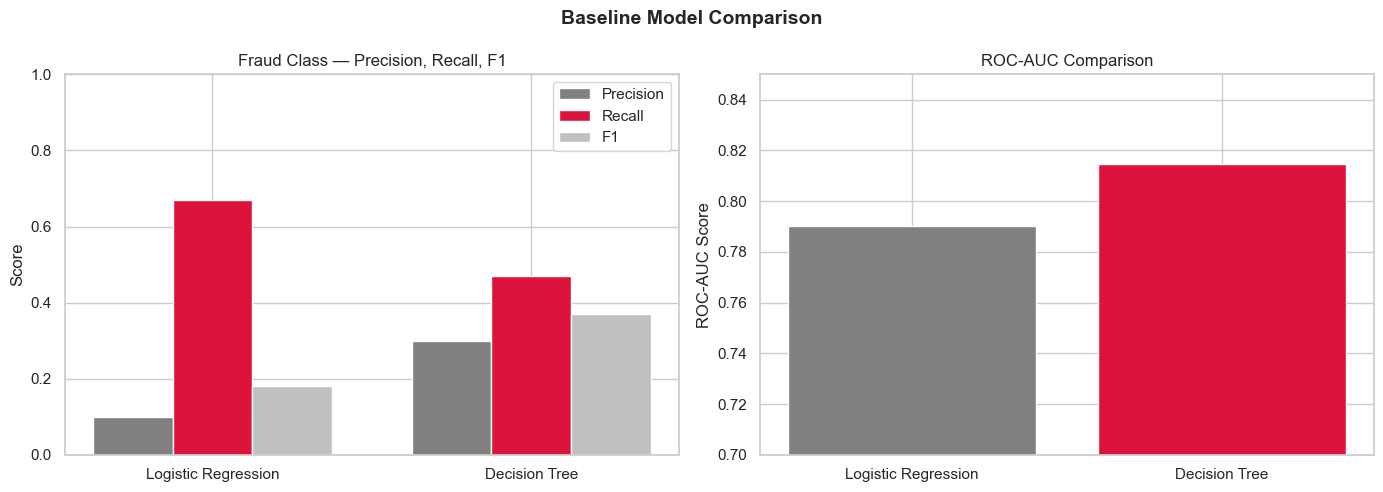

In [5]:
models = ['Logistic Regression', 'Decision Tree']
precision_scores = [0.10, 0.30]
recall_scores = [0.67, 0.47]
f1_scores = [0.18, 0.37]
roc_auc_scores = [0.7902, 0.8146]

x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — precision, recall, F1
bars1 = axes[0].bar(x - width, precision_scores, width, label='Precision', color='grey')
bars2 = axes[0].bar(x, recall_scores, width, label='Recall', color='crimson')
bars3 = axes[0].bar(x + width, f1_scores, width, label='F1', color='silver')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1)
axes[0].set_title('Fraud Class — Precision, Recall, F1')
axes[0].set_ylabel('Score')
axes[0].legend()

# Right chart — ROC-AUC
axes[1].bar(models, roc_auc_scores, color=['grey', 'crimson'], edgecolor='white')
axes[1].set_ylim(0.7, 0.85)
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC Score')

plt.suptitle('Baseline Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()